In [57]:
# # ✈️ Emirates (DXB) Route Profitability & Demand Forecasting
#
# **End-to-end analytics pipeline:** data cleaning → exploratory analysis → profitability
# diagnostics → route segmentation → demand & revenue forecasting → executive dashboard.
#
# | | |
# |---|---|
# | **Dataset** | `Airline_Route_Profitability.csv` — 7,974 flights, 30 routes out of Dubai (DXB), FY2024 |
# | **Business questions** | Which routes/aircraft/seasons drive profit? What drives losses? Can we forecast demand & revenue? |
# | **Author** | *Your Name* |
# | **Repo structure** | `data/` raw data · `notebooks/` this notebook · `outputs/figures` charts · `outputs/reports` cleaned data & summaries |
#
# ---
# ### Table of Contents
# 1. [Setup & Configuration](#1)
# 2. [Data Loading & First Look](#2)
# 3. [Data Quality Audit](#3)
# 4. [Data Cleaning & Feature Engineering](#4)
# 5. [Exploratory Data Analysis](#5)
#    - 5.1 Revenue & Cost Structure
#    - 5.2 Route-Level Profitability
#    - 5.3 Seasonality Effects
#    - 5.4 Fleet / Aircraft Performance
#    - 5.5 Load Factor & Demand
#    - 5.6 Correlation Analysis
# 6. [Route Segmentation (Profitability Matrix)](#6)
# 7. [Profitability Drivers — Feature Importance](#7)
# 8. [Demand Forecasting](#8)
# 9. [Revenue Forecasting](#9)
# 10. [Executive Dashboard](#10)
# 11. [Key Insights & Recommendations](#11)

print("Emirates (DXB) Route Profitability & Demand Forecasting - Notebook Loaded")


## 1. Setup & Configuration <a id='1'></a>

Emirates (DXB) Route Profitability & Demand Forecasting - Notebook Loaded


In [37]:
# --- Core libraries -------------------------------------------------
import warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)

# --- Global plotting style -------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlepad": 12,
    "font.size": 10.5,
    "grid.color": "#dddddd",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "figure.dpi": 100,
})
sns.set_style("whitegrid")

PALETTE      = sns.color_palette("crest", 10)
ACCENT_GREEN = "#1B998B"
ACCENT_RED   = "#D7263D"
ACCENT_GOLD  = "#F2A541"
ACCENT_BLUE  = "#2E4374"
DIVERGING    = sns.diverging_palette(10, 150, s=80, l=45, as_cmap=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# --- Project paths -----------------------------------------------------
BASE_DIR = Path(r"C:\Users\Administrator\Desktop\GitHub Repository\Airline Route Profitability")

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"Project folder not found: {BASE_DIR}\n"
        f"Double-check the folder actually exists at this exact path."
    )

# Search the whole project folder (including subfolders) for any CSV
# whose name contains "airline" or "route" or "profitability" - so we
# don't have to guess the exact filename or subfolder.
csv_candidates = [
    p for p in BASE_DIR.rglob("*.csv")
    if any(k in p.name.lower() for k in ("airline", "route", "profitab"))
]

if len(csv_candidates) == 0:
    print(f"No matching CSV found automatically under: {BASE_DIR}")
    print("Here is everything that IS in that folder, so we can spot it:")
    for item in BASE_DIR.rglob("*"):
        print(" -", item.relative_to(BASE_DIR))
    raise FileNotFoundError("Could not locate the dataset CSV. See file listing above.")
elif len(csv_candidates) > 1:
    print("Multiple matching CSVs found - using the first one, but check this is right:")
    for c in csv_candidates:
        print(" -", c)

DATA_PATH = csv_candidates[0]
print("Using data file:", DATA_PATH)

FIG_DIR     = BASE_DIR / "outputs" / "figures"
REPORT_DIR  = BASE_DIR / "outputs" / "reports"
MODEL_DIR   = BASE_DIR / "outputs" / "models"

for d in (FIG_DIR, REPORT_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, tight=True):
    '''Save a figure into outputs/figures and keep it displayed inline.'''
    if tight:
        fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    print(f"Saved -> outputs/figures/{name}.png")

print("Environment ready.")


Multiple matching CSVs found - using the first one, but check this is right:
 - C:\Users\Administrator\Desktop\GitHub Repository\Airline Route Profitability\Airline_Route_Profitability.csv
 - C:\Users\Administrator\Desktop\GitHub Repository\Airline Route Profitability\outputs\reports\route_profitability_summary.csv
Using data file: C:\Users\Administrator\Desktop\GitHub Repository\Airline Route Profitability\Airline_Route_Profitability.csv
Environment ready.


## 2. Data Loading & First Look <a id='2'></a>

In [38]:

df_raw = pd.read_csv(DATA_PATH)
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")
df_raw.head()


Rows: 7,974  |  Columns: 33


,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Season,Route_Category,Demand_Level,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.7791,14.5,Peak,Long Haul,Medium,410785.49,53431.94,464217.43,131033.88,50750.0,21750.0,65250.0,11600.0,4262.30,5185.86,4460.11,10636.90,78193.60,5100.09,88545.73,25883.92,3769.37,506421.77,-42204.34,-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.7910,4.2,Normal,Medium Haul,Medium,145890.17,17695.27,163585.44,21338.76,9240.0,5040.0,13440.0,2520.0,2016.63,5851.01,5425.84,3027.25,21586.21,6022.20,17057.61,8820.56,1937.81,123323.88,40261.57,24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.8502,7.5,Shoulder,Long Haul,High,602841.03,78724.16,681565.19,41011.77,16500.0,9000.0,24000.0,4500.0,10764.79,4134.08,3761.85,3431.70,100188.97,6514.22,31347.38,23695.34,3415.99,282266.09,399299.10,58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.7748,3.5,Low,Medium Haul,High,126485.16,17543.26,144028.42,17333.86,7700.0,4200.0,11200.0,2100.0,6508.04,6508.73,4440.93,2079.79,22686.82,4791.21,15328.62,6795.49,2245.61,113919.11,30109.31,20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.7901,2.2,Shoulder,Short Haul,Medium,32651.15,3871.66,36522.81,5576.80,2530.0,1716.0,3740.0,616.0,4718.58,3360.52,3414.18,1662.49,5133.62,3094.65,8252.23,1492.53,1273.27,46580.86,-10058.06,-27.54


In [39]:

df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7974 entries, 0 to 7973
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Flight_Number            7974 non-null   object 
 1   Flight_Date              7974 non-null   object 
 2   Origin                   7974 non-null   object 
 3   Destination              7974 non-null   object 
 4   Route                    7974 non-null   object 
 5   Aircraft_Type            7974 non-null   object 
 6   Aircraft_Capacity        7974 non-null   int64  
 7   Passengers               7974 non-null   int64  
 8   Load_Factor              7974 non-null   float64
 9   Flight_Hours             7974 non-null   float64
 10  Season                   7974 non-null   object 
 11  Route_Category           7974 non-null   object 
 12  Demand_Level             7974 non-null   object 
 13  Ticket_Revenue           7974 non-null   float64
 14  Ancillary_Revenue       

## 3. Data Quality Audit <a id='3'></a>
Before touching the data, we audit it: missing values, duplicates, and whether the
derived columns (`Total_Revenue`, `Total_Cost`, `Profit`) are internally consistent
with their components.

In [40]:

miss = df_raw.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
print(missing_summary)
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("Flight_Number duplicates:", df_raw.Flight_Number.duplicated().sum())


                   missing_count  missing_pct
Ancillary_Revenue            271         3.40
Catering_Cost                265         3.32
Handling_Cost                256         3.21

Duplicate rows: 0
Flight_Number duplicates: 0


Saved -> outputs/figures/01_missing_data.png


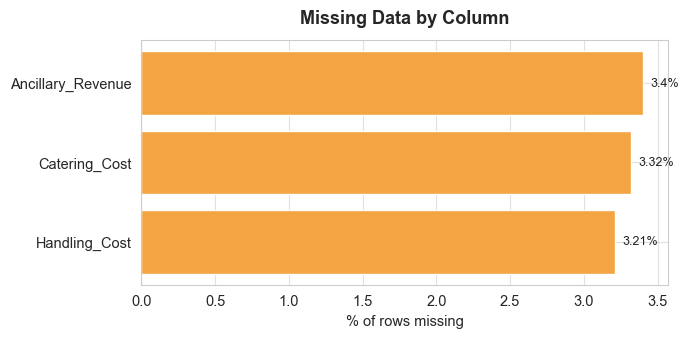

In [41]:

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(missing_summary.index, missing_summary.missing_pct, color=ACCENT_GOLD, edgecolor="white")
ax.set_xlabel("% of rows missing")
ax.set_title("Missing Data by Column")
for b, v in zip(bars, missing_summary.missing_pct):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2, f"{v}%", va="center", fontsize=9)
ax.invert_yaxis()
savefig(fig, "01_missing_data")
plt.show()


In [42]:

# Sanity-check the arithmetic relationships that the data dictionary implies
rev_check  = (df_raw.Ticket_Revenue + df_raw.Ancillary_Revenue.fillna(0) - df_raw.Total_Revenue).abs()
cost_cols  = ["Fuel_Cost","Maintenance_Cost","Crew_Cost","Depreciation_Cost","Insurance_Cost",
              "Airport_Fees","Catering_Cost","Handling_Cost","Navigation_Fees",
              "Sales_Distribution_Cost","Passenger_Service_Cost","Overhead_Cost",
              "Marketing_Cost","IT_Systems_Cost"]
cost_check = (df_raw[cost_cols].sum(axis=1, skipna=True) - df_raw.Total_Cost).abs()
profit_check = (df_raw.Total_Revenue - df_raw.Total_Cost - df_raw.Profit).abs()

print("Rows where Total_Revenue is fully consistent with components:",
      (rev_check[df_raw.Ancillary_Revenue.notna()] < 0.05).mean().round(4))
print("Max |Profit - (Revenue-Cost)| discrepancy:", profit_check.max())
print("\n=> Total_Revenue and Total_Cost are ALWAYS complete, even when a component\n"
      "   (Ancillary_Revenue / Catering_Cost / Handling_Cost) is missing.\n"
      "   That means missing components can be recovered algebraically instead of\n"
      "   being imputed: a much more accurate fix than mean/median filling.")


Rows where Total_Revenue is fully consistent with components: 1.0
Max |Profit - (Revenue-Cost)| discrepancy: 0.010000000125728548

=> Total_Revenue and Total_Cost are ALWAYS complete, even when a component
   (Ancillary_Revenue / Catering_Cost / Handling_Cost) is missing.
   That means missing components can be recovered algebraically instead of
   being imputed — a much more accurate fix than mean/median filling.


## 4. Data Cleaning & Feature Engineering <a id='4'></a>
**Cleaning strategy**
1. Recover missing `Ancillary_Revenue` as `Total_Revenue - Ticket_Revenue` (exact, not estimated).
2. Recover missing `Catering_Cost` / `Handling_Cost` as the residual of `Total_Cost` minus all other known cost components.
3. Parse dates, enforce dtypes, and check for logical bounds (Load_Factor in [0,1], no negative revenue/cost).
4. Engineer time, unit-economics and cost-structure features used throughout the analysis.

In [43]:

df = df_raw.copy()

# --- 4.1 Recover missing values algebraically ------------------------
df["Ancillary_Revenue"] = df["Ancillary_Revenue"].fillna(df["Total_Revenue"] - df["Ticket_Revenue"])

other_known_when_catering_missing = [c for c in cost_cols if c != "Catering_Cost"]
df.loc[df.Catering_Cost.isna(), "Catering_Cost"] = (
    df.loc[df.Catering_Cost.isna(), "Total_Cost"] - df.loc[df.Catering_Cost.isna(), other_known_when_catering_missing].sum(axis=1)
)
other_known_when_handling_missing = [c for c in cost_cols if c != "Handling_Cost"]
df.loc[df.Handling_Cost.isna(), "Handling_Cost"] = (
    df.loc[df.Handling_Cost.isna(), "Total_Cost"] - df.loc[df.Handling_Cost.isna(), other_known_when_handling_missing].sum(axis=1)
)

assert df.isna().sum().sum() == 0, "Unexpected missing values remain!"
print("Missing values remaining:", df.isna().sum().sum())

# --- 4.2 Dtypes & bounds ----------------------------------------------
df["Flight_Date"] = pd.to_datetime(df["Flight_Date"])
assert df.Load_Factor.between(0, 1).all(), "Load factor out of bounds"
assert (df[["Total_Revenue","Total_Cost","Passengers"]] >= 0).all().all(), "Negative values found"

# --- 4.3 Time features --------------------------------------------------
df["Month"]        = df.Flight_Date.dt.month
df["MonthName"]    = df.Flight_Date.dt.strftime("%b")
df["Quarter"]      = df.Flight_Date.dt.quarter
df["Weekday"]      = df.Flight_Date.dt.day_name()
df["YearMonth"]    = df.Flight_Date.dt.to_period("M").astype(str)
df["Week"]         = df.Flight_Date.dt.isocalendar().week.astype(int)

# --- 4.4 Cost-structure grouping ----------------------------------------
df["Direct_Op_Cost"]   = df[["Fuel_Cost","Maintenance_Cost","Crew_Cost","Depreciation_Cost","Insurance_Cost"]].sum(axis=1)
df["Service_Cost"]     = df[["Airport_Fees","Catering_Cost","Handling_Cost","Navigation_Fees"]].sum(axis=1)
df["Indirect_Cost"]    = df[["Sales_Distribution_Cost","Passenger_Service_Cost","Overhead_Cost","Marketing_Cost","IT_Systems_Cost"]].sum(axis=1)

# --- 4.5 Unit economics ---------------------------------------------------
df["Revenue_per_Pax"]  = df.Total_Revenue / df.Passengers
df["Cost_per_Pax"]     = df.Total_Cost / df.Passengers
df["Profit_per_Pax"]   = df.Profit / df.Passengers
df["ASK"]              = df.Aircraft_Capacity * df.Flight_Hours          # available-seat-hours (distance proxy)
df["RASK"]             = df.Total_Revenue / df.ASK                        # revenue per available-seat-hour
df["CASK"]             = df.Total_Cost / df.ASK                           # cost per available-seat-hour
df["Is_Profitable"]    = df.Profit > 0

print(f"Final shape: {df.shape}")
print(f"Date range: {df.Flight_Date.min().date()} -> {df.Flight_Date.max().date()}")
df[["Ancillary_Revenue","Catering_Cost","Handling_Cost","Direct_Op_Cost","Service_Cost",
    "Indirect_Cost","Revenue_per_Pax","Cost_per_Pax","RASK","CASK"]].describe().T


Missing values remaining: 0
Final shape: (7974, 49)
Date range: 2024-01-01 -> 2024-12-31


,count,mean,std,min,25%,50%,75%,max
Ancillary_Revenue,7974.0,33052.324090,30133.939765,1616.620000,7238.675000,22801.245000,51187.137500,192921.910000
Catering_Cost,7974.0,5997.968715,2726.795301,1398.400000,3965.245000,5511.140000,7494.447500,17079.700000
Handling_Cost,7974.0,3987.193241,1148.627238,2000.040000,2982.232500,3971.435000,4974.580000,5999.980000
Direct_Op_Cost,7974.0,103938.508210,94020.160069,7284.620000,39177.575000,63800.945000,171046.297500,394047.780000
Service_Cost,7974.0,18825.642789,6302.178083,6723.170000,13606.280000,17792.350000,23175.082500,42282.280000
Indirect_Cost,7974.0,102502.412701,79934.512303,11898.840000,32377.782500,74383.210000,158494.687500,422786.270000
Revenue_per_Pax,7974.0,1014.438636,715.225858,135.240000,362.650660,788.477114,1594.175718,3070.075639
Cost_per_Pax,7974.0,795.094533,481.139540,188.040645,413.577449,605.028057,1088.818834,2294.760307
RASK,7974.0,140.227779,66.920886,24.317705,87.523491,128.040037,182.463553,445.340434
CASK,7974.0,111.493864,26.959523,66.492011,92.151473,104.376773,124.054409,233.369709


In [44]:

# Persist the cleaned dataset for reproducibility / downstream use
df.to_csv(REPORT_DIR / "cleaned_flight_data.csv", index=False)
print("Saved -> outputs/reports/cleaned_flight_data.csv")


Saved -> outputs/reports/cleaned_flight_data.csv


Profit_Margin IQR bounds: [-76.8%, 99.3%]  |  Outlier flights: 319 (4.0%)
Decision: kept — these are real loss-making / high-margin flights that are exactly
what a profitability analysis needs to surface, not data errors.
Saved -> outputs/figures/02_profit_margin_outlier_check.png


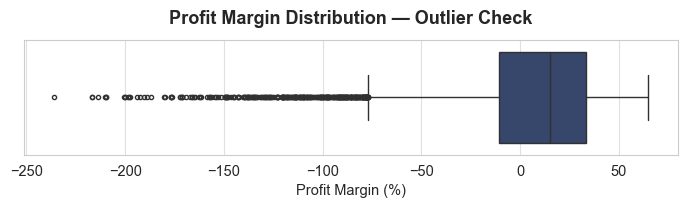

In [45]:

# Outlier check on Profit_Margin (business KPI) - IQR method, informational only
q1, q3 = df.Profit_Margin.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df.Profit_Margin < lo) | (df.Profit_Margin > hi)]
print(f"Profit_Margin IQR bounds: [{lo:.1f}%, {hi:.1f}%]  |  Outlier flights: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print("Decision: kept these are real loss-making / high-margin flights that are exactly")
print("what a profitability analysis needs to surface, not data errors.")

fig, ax = plt.subplots(figsize=(7,2.2))
sns.boxplot(x=df.Profit_Margin, ax=ax, color=ACCENT_BLUE, fliersize=3)
ax.set_title("Profit Margin Distribution: Outlier Check")
ax.set_xlabel("Profit Margin (%)")
savefig(fig, "02_profit_margin_outlier_check")
plt.show()


## 5. Exploratory Data Analysis <a id='5'></a>

### 5.1 Revenue & Cost Structure

Saved -> outputs/figures/03_revenue_profit_distributions.png


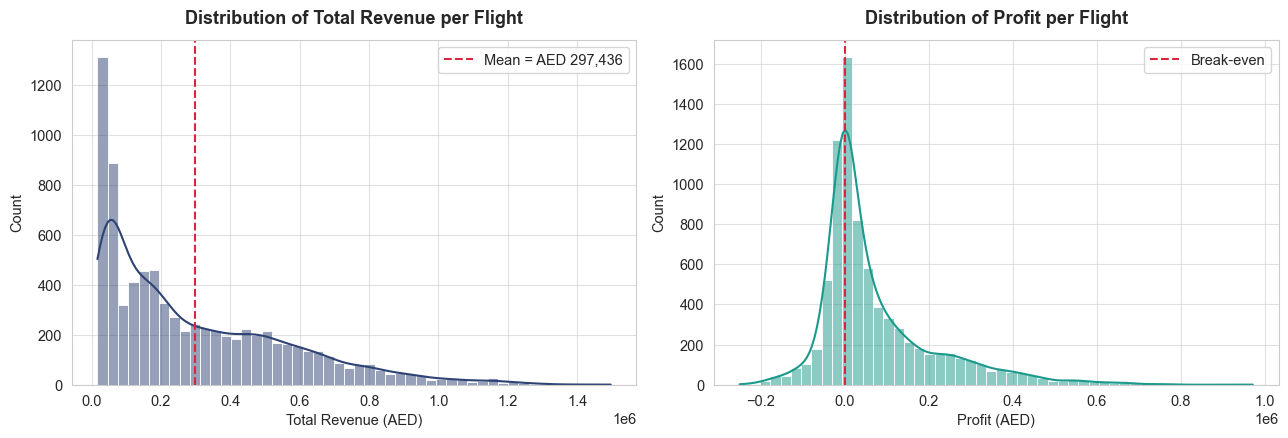

Share of loss-making flights: 33.7%


In [46]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df.Total_Revenue, bins=50, color=ACCENT_BLUE, ax=axes[0], kde=True)
axes[0].axvline(df.Total_Revenue.mean(), color=ACCENT_RED, ls="--", lw=1.5, label=f"Mean = AED {df.Total_Revenue.mean():,.0f}")
axes[0].set_title("Distribution of Total Revenue per Flight")
axes[0].set_xlabel("Total Revenue (AED)")
axes[0].legend()

sns.histplot(df.Profit, bins=50, color=ACCENT_GREEN, ax=axes[1], kde=True)
axes[1].axvline(0, color=ACCENT_RED, ls="--", lw=1.5, label="Break-even")
axes[1].set_title("Distribution of Profit per Flight")
axes[1].set_xlabel("Profit (AED)")
axes[1].legend()

savefig(fig, "03_revenue_profit_distributions")
plt.show()

loss_share = (df.Profit < 0).mean() * 100
print(f"Share of loss-making flights: {loss_share:.1f}%")


Saved -> outputs/figures/04_cost_structure.png


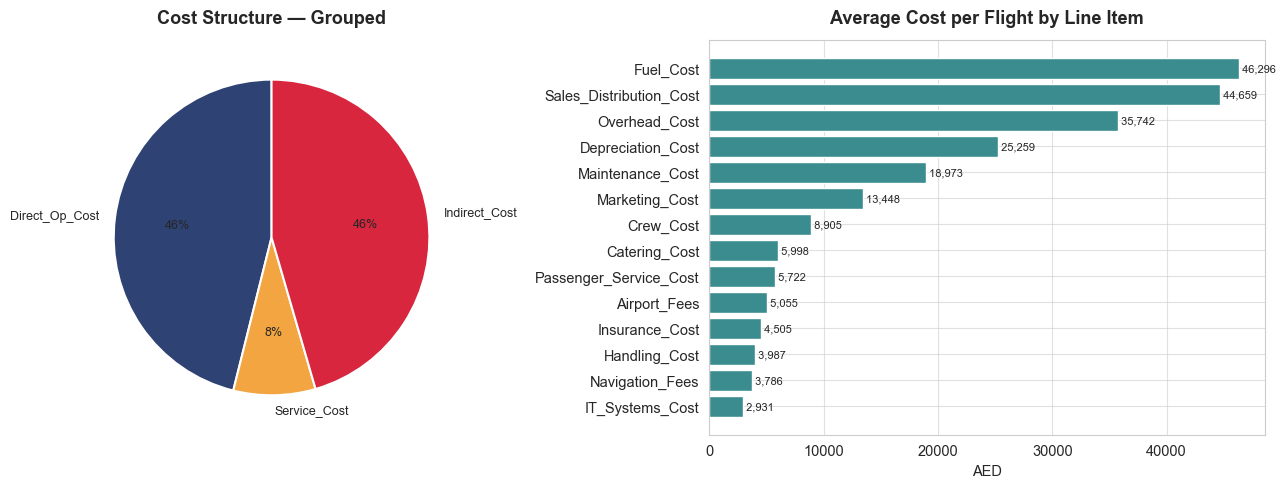

Fuel cost is the single largest line item, followed by sales distribution & overhead.


In [47]:

# Average cost composition (direct / service / indirect) as % of total cost
cost_group_cols = ["Direct_Op_Cost", "Service_Cost", "Indirect_Cost"]
avg_costs = df[cost_group_cols].mean()
avg_costs_pct = (avg_costs / avg_costs.sum() * 100).round(1)

fine_cost_cols = ["Fuel_Cost","Maintenance_Cost","Crew_Cost","Depreciation_Cost","Insurance_Cost",
                   "Airport_Fees","Catering_Cost","Handling_Cost","Navigation_Fees",
                   "Sales_Distribution_Cost","Passenger_Service_Cost","Overhead_Cost",
                   "Marketing_Cost","IT_Systems_Cost"]
fine_avg = df[fine_cost_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios":[1,1.4]})

colors_pie = [ACCENT_BLUE, ACCENT_GOLD, ACCENT_RED]
wedges, _, autotexts = axes[0].pie(avg_costs_pct, labels=cost_group_cols, autopct="%1.0f%%",
                                     colors=colors_pie, startangle=90,
                                     wedgeprops={"edgecolor":"white","linewidth":1.5},
                                     textprops={"fontsize":9})
axes[0].set_title("Cost Structure: Grouped")

bars = axes[1].barh(fine_avg.index[::-1], fine_avg.values[::-1], color=PALETTE[4])
axes[1].set_title("Average Cost per Flight by Line Item")
axes[1].set_xlabel("AED")
for b, v in zip(bars, fine_avg.values[::-1]):
    axes[1].text(v, b.get_y()+b.get_height()/2, f" {v:,.0f}", va="center", fontsize=8)

savefig(fig, "04_cost_structure")
plt.show()
print("Fuel cost is the single largest line item, followed by sales distribution & overhead.")


### 5.2 Route-Level Profitability

In [48]:

route_summary = (df.groupby("Route")
                    .agg(Flights=("Flight_Number","count"),
                         Avg_Load_Factor=("Load_Factor","mean"),
                         Total_Revenue=("Total_Revenue","sum"),
                         Total_Cost=("Total_Cost","sum"),
                         Total_Profit=("Profit","sum"),
                         Avg_Profit_Margin=("Profit_Margin","mean"),
                         Route_Category=("Route_Category","first"),
                         Demand_Level=("Demand_Level","first"))
                    .sort_values("Total_Profit", ascending=False)
                    .reset_index())
route_summary.to_csv(REPORT_DIR / "route_profitability_summary.csv", index=False)
print("Saved -> outputs/reports/route_profitability_summary.csv")
route_summary.head(10)


Saved -> outputs/reports/route_profitability_summary.csv


,Route,Flights,Avg_Load_Factor,Total_Revenue,Total_Cost,Total_Profit,Avg_Profit_Margin,Route_Category,Demand_Level
0,DXB-FRA,325,0.850049,2.048922e+08,1.054007e+08,99491502.54,46.080000,Long Haul,High
1,DXB-SIN,320,0.849792,2.039344e+08,1.129396e+08,90994879.30,42.072750,Long Haul,High
2,DXB-CDG,323,0.853367,2.039859e+08,1.138073e+08,90178585.87,41.265944,Long Haul,High
3,DXB-HKG,332,0.851442,2.182465e+08,1.287146e+08,89531878.76,38.667681,Long Haul,High
4,DXB-JFK,328,0.851404,2.137032e+08,1.724657e+08,41237491.55,15.704177,Long Haul,High
5,DXB-BKK,212,0.740103,9.495948e+07,5.439553e+07,40563948.78,39.905236,Long Haul,Medium
6,DXB-KUL,216,0.727525,9.641778e+07,5.993626e+07,36481521.99,34.485741,Long Haul,Medium
7,DXB-SYD,327,0.848955,2.053551e+08,1.742288e+08,31126294.37,9.975076,Long Haul,High
8,DXB-BOM,325,0.848457,6.903962e+07,4.496927e+07,24070355.00,31.157938,Medium Haul,High
9,DXB-DEL,332,0.852158,6.803000e+07,4.697777e+07,21052229.00,27.435934,Medium Haul,High


Saved -> outputs/figures/05_top_bottom_routes.png


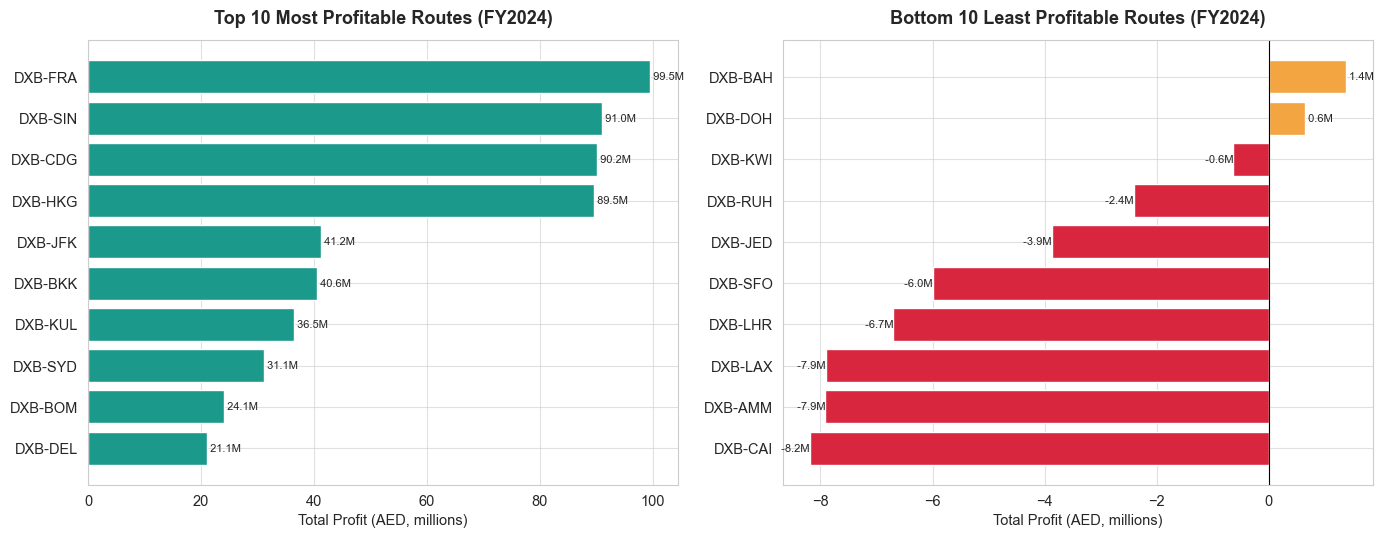

8 of 30 routes are net loss-making for the year.


In [49]:

top10 = route_summary.head(10)
bottom10 = route_summary.tail(10).sort_values("Total_Profit")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

b1 = axes[0].barh(top10.Route, top10.Total_Profit/1e6, color=ACCENT_GREEN)
axes[0].set_title("Top 10 Most Profitable Routes (FY2024)")
axes[0].set_xlabel("Total Profit (AED, millions)")
axes[0].invert_yaxis()
for b,v in zip(b1, top10.Total_Profit/1e6):
    axes[0].text(v, b.get_y()+b.get_height()/2, f" {v:.1f}M", va="center", fontsize=8)

b2 = axes[1].barh(bottom10.Route, bottom10.Total_Profit/1e6,
                   color=[ACCENT_RED if v < 0 else ACCENT_GOLD for v in bottom10.Total_Profit])
axes[1].set_title("Bottom 10 Least Profitable Routes (FY2024)")
axes[1].set_xlabel("Total Profit (AED, millions)")
axes[1].axvline(0, color="black", lw=0.8)
for b,v in zip(b2, bottom10.Total_Profit/1e6):
    axes[1].text(v, b.get_y()+b.get_height()/2, f" {v:.1f}M", va="center",
                 ha="left" if v>=0 else "right", fontsize=8)

savefig(fig, "05_top_bottom_routes")
plt.show()

n_loss_routes = (route_summary.Total_Profit < 0).sum()
print(f"{n_loss_routes} of {len(route_summary)} routes are net loss-making for the year.")


Saved -> outputs/figures/06_route_profitability_map.png


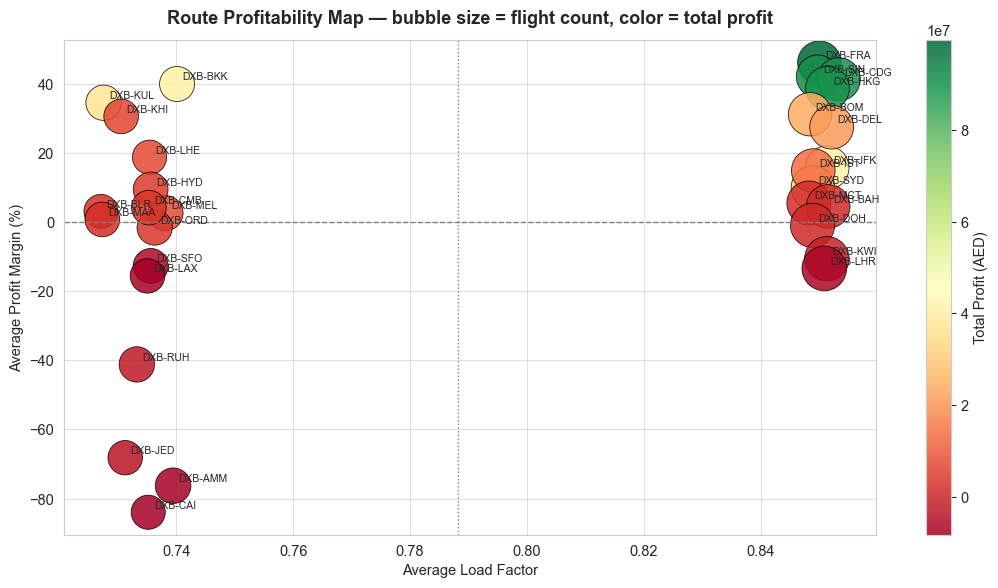

In [50]:

fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(route_summary.Avg_Load_Factor, route_summary.Avg_Profit_Margin,
                      s=route_summary.Flights*3, c=route_summary.Total_Profit,
                      cmap="RdYlGn", edgecolor="black", linewidth=0.6, alpha=0.85)
for _, r in route_summary.iterrows():
    ax.annotate(r.Route, (r.Avg_Load_Factor, r.Avg_Profit_Margin), fontsize=7.5,
                xytext=(4,3), textcoords="offset points")
ax.axhline(0, color="grey", ls="--", lw=1)
ax.axvline(route_summary.Avg_Load_Factor.mean(), color="grey", ls=":", lw=1)
ax.set_xlabel("Average Load Factor")
ax.set_ylabel("Average Profit Margin (%)")
ax.set_title("Route Profitability Map: bubble size = flight count, color = total profit")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Total Profit (AED)")
savefig(fig, "06_route_profitability_map")
plt.show()


### 5.3 Seasonality Effects

Saved -> outputs/figures/07_monthly_revenue_cost_profit.png


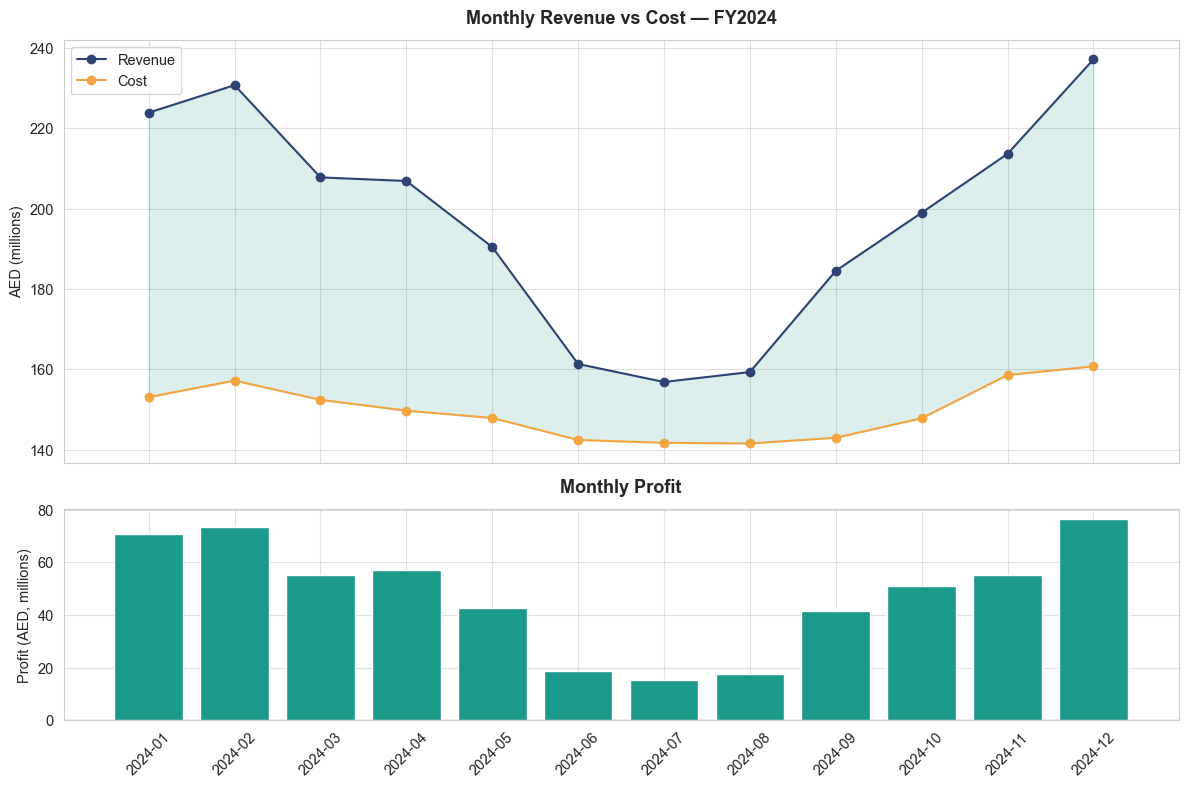

In [51]:

season_order = ["Low","Shoulder","Normal","Peak"]
monthly = df.groupby("YearMonth").agg(Revenue=("Total_Revenue","sum"),
                                       Cost=("Total_Cost","sum"),
                                       Profit=("Profit","sum"),
                                       Passengers=("Passengers","sum")).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                          gridspec_kw={"height_ratios":[2,1]})

axes[0].plot(monthly.YearMonth, monthly.Revenue/1e6, marker="o", color=ACCENT_BLUE, label="Revenue")
axes[0].plot(monthly.YearMonth, monthly.Cost/1e6, marker="o", color=ACCENT_GOLD, label="Cost")
axes[0].fill_between(monthly.YearMonth, monthly.Revenue/1e6, monthly.Cost/1e6,
                      where=(monthly.Revenue>=monthly.Cost), color=ACCENT_GREEN, alpha=0.15)
axes[0].set_ylabel("AED (millions)")
axes[0].set_title("Monthly Revenue vs Cost: FY2024")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

colors_bar = [ACCENT_GREEN if p>=0 else ACCENT_RED for p in monthly.Profit]
axes[1].bar(monthly.YearMonth, monthly.Profit/1e6, color=colors_bar)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Profit (AED, millions)")
axes[1].set_title("Monthly Profit")
axes[1].tick_params(axis="x", rotation=45)

savefig(fig, "07_monthly_revenue_cost_profit")
plt.show()


Saved -> outputs/figures/08_seasonality_effects.png


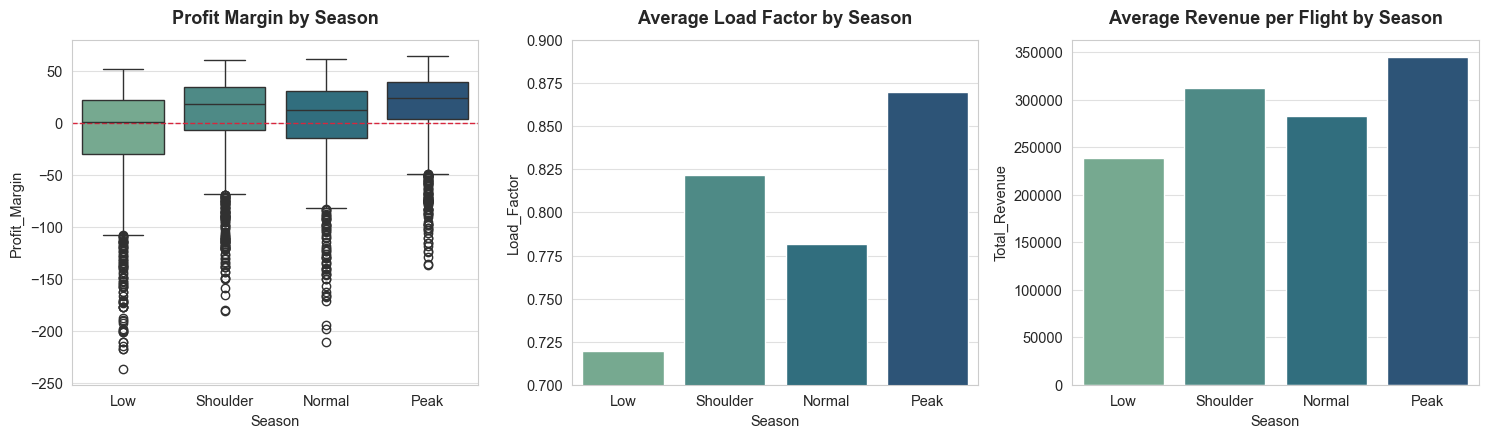

Season
Low         -8.50
Shoulder    10.14
Normal       3.33
Peak        17.55
Name: Profit_Margin, dtype: float64


In [52]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df, x="Season", y="Profit_Margin", order=season_order, ax=axes[0], palette="crest")
axes[0].axhline(0, color=ACCENT_RED, ls="--", lw=1)
axes[0].set_title("Profit Margin by Season")

sns.barplot(data=df, x="Season", y="Load_Factor", order=season_order, ax=axes[1],
            estimator=np.mean, palette="crest", errorbar=None)
axes[1].set_title("Average Load Factor by Season")
axes[1].set_ylim(0.7, 0.9)

sns.barplot(data=df, x="Season", y="Total_Revenue", order=season_order, ax=axes[2],
            estimator=np.mean, palette="crest", errorbar=None)
axes[2].set_title("Average Revenue per Flight by Season")

savefig(fig, "08_seasonality_effects")
plt.show()

season_profit = df.groupby("Season")["Profit_Margin"].mean().reindex(season_order)
print(season_profit.round(2))


### 5.4 Fleet / Aircraft Performance

In [53]:

fleet = (df.groupby("Aircraft_Type")
           .agg(Flights=("Flight_Number","count"),
                Avg_Load_Factor=("Load_Factor","mean"),
                Avg_Profit_Margin=("Profit_Margin","mean"),
                Avg_CASK=("CASK","mean"),
                Avg_RASK=("RASK","mean"),
                Total_Profit=("Profit","sum"))
           .sort_values("Total_Profit", ascending=False))
fleet


,Flights,Avg_Load_Factor,Avg_Profit_Margin,Avg_CASK,Avg_RASK,Total_Profit
Aircraft_Type,,,,,,
Boeing 777-300ER,1690,0.806732,17.259136,103.549395,146.546342,1.951387e+08
Airbus A380,793,0.847843,23.181375,108.257010,163.651817,1.811070e+08
Boeing 787-9,1818,0.804445,9.478240,102.964752,137.915643,1.335841e+08
Airbus A350-900,1700,0.759275,1.040706,96.053690,116.226214,6.257166e+07
Airbus A320,956,0.811496,-7.872992,141.874975,150.868561,2.044150e+06
Boeing 737-800,1017,0.813140,-9.502458,139.716932,145.714412,1.035013e+06


Saved -> outputs/figures/09_fleet_performance.png


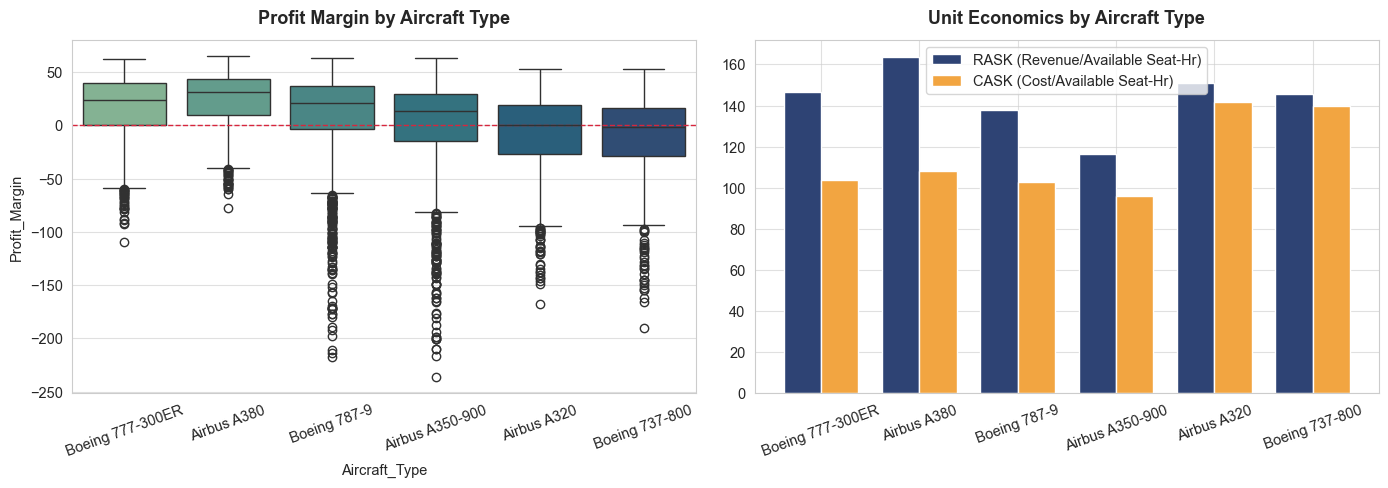

In [54]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = fleet.index
sns.boxplot(data=df, x="Aircraft_Type", y="Profit_Margin", order=order, ax=axes[0], palette="crest")
axes[0].axhline(0, color=ACCENT_RED, ls="--", lw=1)
axes[0].set_title("Profit Margin by Aircraft Type")
axes[0].tick_params(axis="x", rotation=20)

x = np.arange(len(fleet))
width = 0.38
axes[1].bar(x - width/2, fleet.Avg_RASK, width, label="RASK (Revenue/Available Seat-Hr)", color=ACCENT_BLUE)
axes[1].bar(x + width/2, fleet.Avg_CASK, width, label="CASK (Cost/Available Seat-Hr)", color=ACCENT_GOLD)
axes[1].set_xticks(x); axes[1].set_xticklabels(fleet.index, rotation=20)
axes[1].set_title("Unit Economics by Aircraft Type")
axes[1].legend()

savefig(fig, "09_fleet_performance")
plt.show()


### 5.5 Load Factor & Demand

Saved -> outputs/figures/10_loadfactor_demand.png


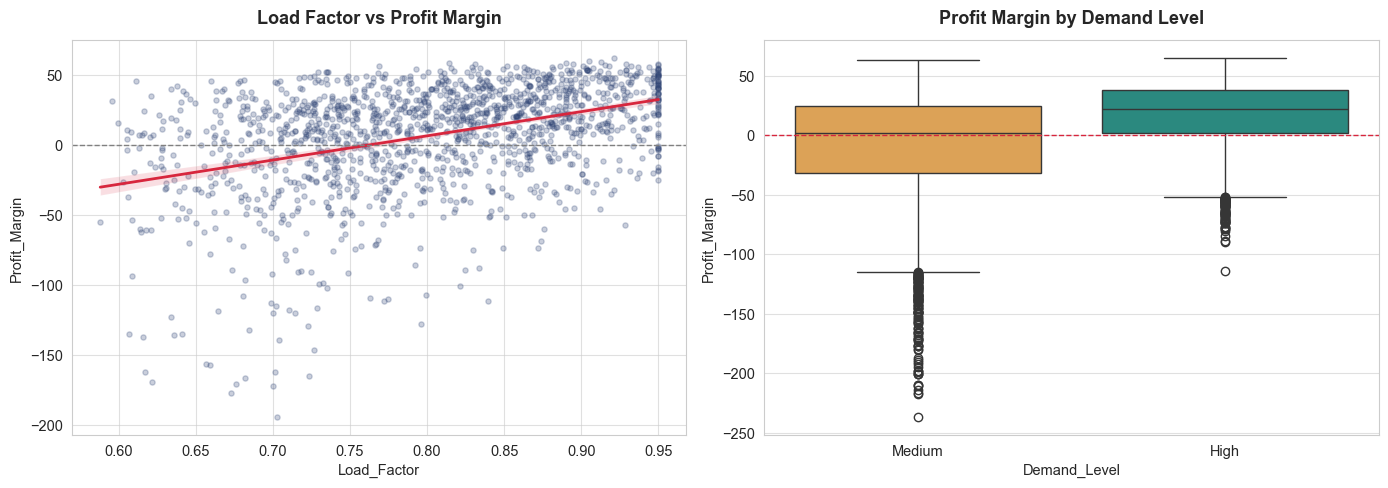

Correlation(Load Factor, Profit Margin) = 0.416


In [23]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df.sample(1500, random_state=42), x="Load_Factor", y="Profit_Margin",
            scatter_kws={"alpha":0.25,"s":14,"color":ACCENT_BLUE},
            line_kws={"color":ACCENT_RED,"lw":2}, ax=axes[0])
axes[0].axhline(0, color="grey", ls="--", lw=1)
axes[0].set_title("Load Factor vs Profit Margin")

sns.boxplot(data=df, x="Demand_Level", y="Profit_Margin", ax=axes[1], palette=["#F2A541","#1B998B"])
axes[1].axhline(0, color=ACCENT_RED, ls="--", lw=1)
axes[1].set_title("Profit Margin by Demand Level")

savefig(fig, "10_loadfactor_demand")
plt.show()

corr_lf_pm = df.Load_Factor.corr(df.Profit_Margin)
print(f"Correlation(Load Factor, Profit Margin) = {corr_lf_pm:.3f}")


### 5.6 Correlation Analysis

Saved -> outputs/figures/11_correlation_heatmap.png


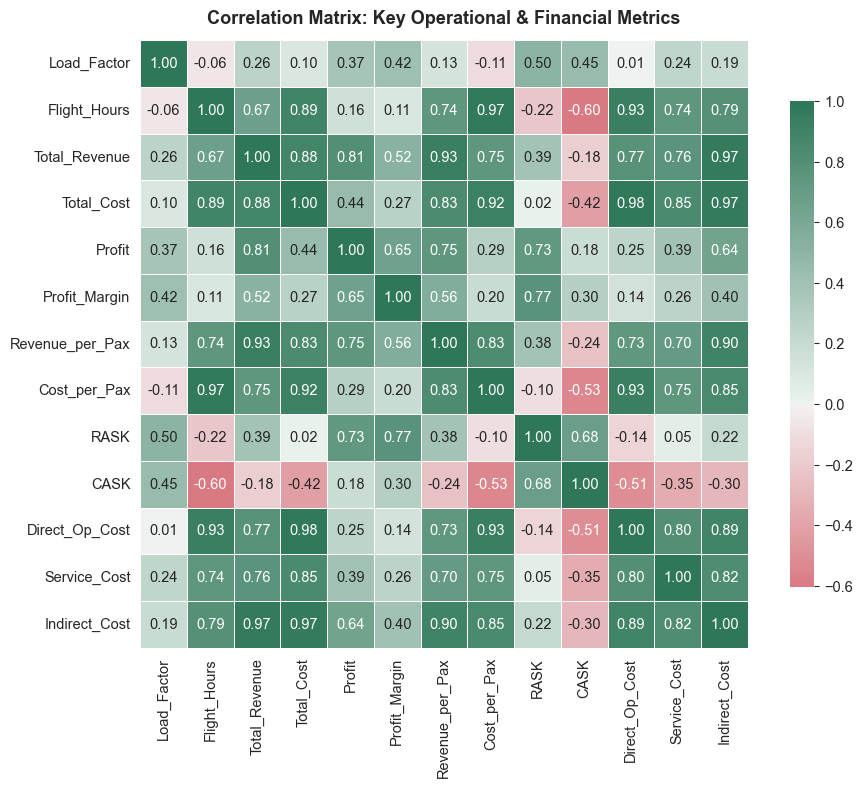

In [55]:

num_cols = ["Load_Factor","Flight_Hours","Total_Revenue","Total_Cost","Profit","Profit_Margin",
            "Revenue_per_Pax","Cost_per_Pax","RASK","CASK","Direct_Op_Cost","Service_Cost","Indirect_Cost"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink":0.8}, ax=ax)
ax.set_title("Correlation Matrix: Key Operational & Financial Metrics")
savefig(fig, "11_correlation_heatmap")
plt.show()


## 6. Route Segmentation: Profitability Matrix <a id='6'></a>
We segment the 30 routes into strategic tiers using **K-Means clustering** on
`Avg_Load_Factor` and `Avg_Profit_Margin` (standardized), producing a BCG-style
matrix: **Stars**, **Cash Cows**, **Question Marks**, and **Underperformers**.

  File "C:\Users\Administrator\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Administrator\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Saved -> outputs/figures/12_route_segmentation.png


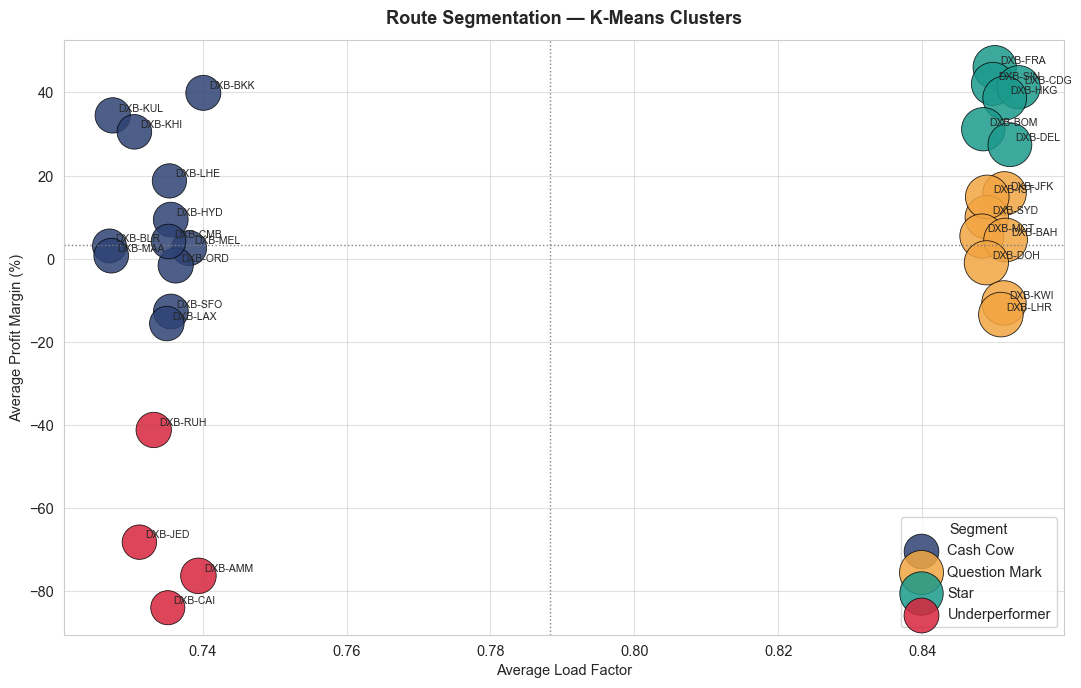

                Routes  Total_Profit
Segment                             
Star                 6  4.153194e+08
Cash Cow            12  1.003150e+08
Question Mark        8  8.223770e+07
Underperformer       4 -2.239143e+07


In [25]:

seg_features = route_summary[["Avg_Load_Factor","Avg_Profit_Margin"]].copy()
scaler = StandardScaler()
X_seg = scaler.fit_transform(seg_features)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
route_summary["Cluster"] = kmeans.fit_predict(X_seg)

# Label clusters by their mean profit margin / load factor for interpretability
cluster_stats = route_summary.groupby("Cluster")[["Avg_Load_Factor","Avg_Profit_Margin"]].mean()
label_map = {}
overall_lf = route_summary.Avg_Load_Factor.mean()
overall_pm = route_summary.Avg_Profit_Margin.mean()
for cl, row in cluster_stats.iterrows():
    if row.Avg_Profit_Margin >= overall_pm and row.Avg_Load_Factor >= overall_lf:
        label_map[cl] = "Star"
    elif row.Avg_Profit_Margin >= overall_pm and row.Avg_Load_Factor < overall_lf:
        label_map[cl] = "Cash Cow"
    elif row.Avg_Profit_Margin < overall_pm and row.Avg_Load_Factor >= overall_lf:
        label_map[cl] = "Question Mark"
    else:
        label_map[cl] = "Underperformer"
route_summary["Segment"] = route_summary.Cluster.map(label_map)

seg_colors = {"Star":ACCENT_GREEN, "Cash Cow":ACCENT_BLUE, "Question Mark":ACCENT_GOLD, "Underperformer":ACCENT_RED}

fig, ax = plt.subplots(figsize=(11, 7))
for seg, sub in route_summary.groupby("Segment"):
    ax.scatter(sub.Avg_Load_Factor, sub.Avg_Profit_Margin, s=sub.Flights*3,
               color=seg_colors[seg], edgecolor="black", linewidth=0.6, alpha=0.85, label=seg)
    for _, r in sub.iterrows():
        ax.annotate(r.Route, (r.Avg_Load_Factor, r.Avg_Profit_Margin), fontsize=7.5,
                    xytext=(4,3), textcoords="offset points")
ax.axhline(overall_pm, color="grey", ls=":", lw=1)
ax.axvline(overall_lf, color="grey", ls=":", lw=1)
ax.set_xlabel("Average Load Factor")
ax.set_ylabel("Average Profit Margin (%)")
ax.set_title("Route Segmentation: K-Means Clusters")
ax.legend(title="Segment")
savefig(fig, "12_route_segmentation")
plt.show()

print(route_summary.groupby("Segment").agg(Routes=("Route","count"), Total_Profit=("Total_Profit","sum")).sort_values("Total_Profit", ascending=False))
route_summary.to_csv(REPORT_DIR / "route_profitability_summary.csv", index=False)


## 7. Profitability Drivers: Feature Importance <a id='7'></a>
A Random Forest regressor is trained to predict **Profit_Margin** from operational
features (not from the cost/revenue columns that mechanically define it), so the
importances tell us what *operational* levers matter most.

Saved -> outputs/figures/13_feature_importance.png


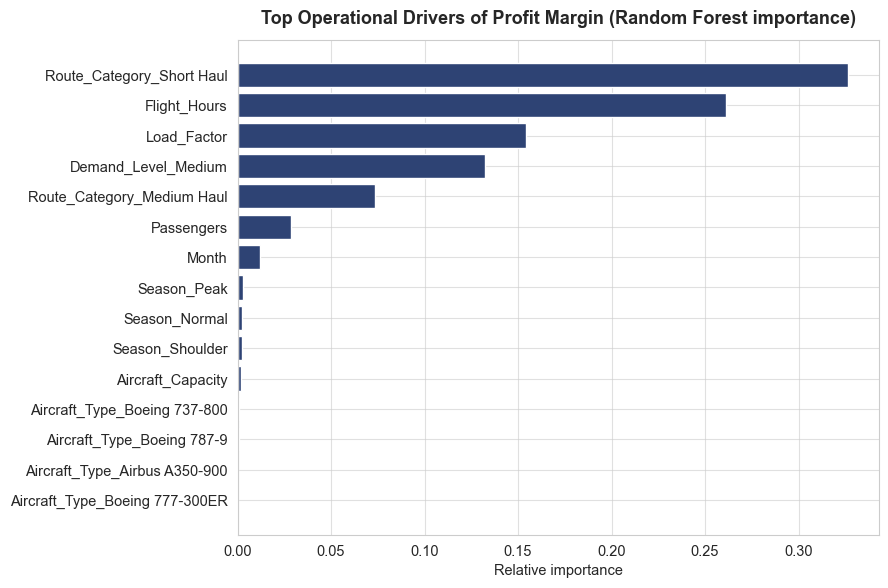

Model R² (in-sample, explanatory not predictive use): 0.783


In [26]:

model_df = df.copy()
cat_cols = ["Aircraft_Type","Season","Route_Category","Demand_Level"]
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

feature_cols = ["Load_Factor","Flight_Hours","Aircraft_Capacity","Passengers","Month"] + \
               [c for c in model_df.columns if any(c.startswith(p) for p in cat_cols)]
X = model_df[feature_cols]
y = model_df["Profit_Margin"]

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index[::-1], importances.values[::-1], color=ACCENT_BLUE)
ax.set_title("Top Operational Drivers of Profit Margin (Random Forest importance)")
ax.set_xlabel("Relative importance")
savefig(fig, "13_feature_importance")
plt.show()

print(f"Model R² (in-sample, explanatory not predictive use): {r2_score(y, rf.predict(X)):.3f}")


## 8. Demand Forecasting <a id='8'></a>
We aggregate to a **weekly** grain (53 weeks in FY2024) smoother than daily, still
granular enough to forecast a few weeks ahead. We build lag / rolling-window features
and benchmark a linear trend+seasonality model against a Random Forest, then forecast
the next 6 weeks recursively.

Using 52 complete weeks (partial first/last weeks excluded).
Saved -> outputs/figures/14_weekly_demand_series.png


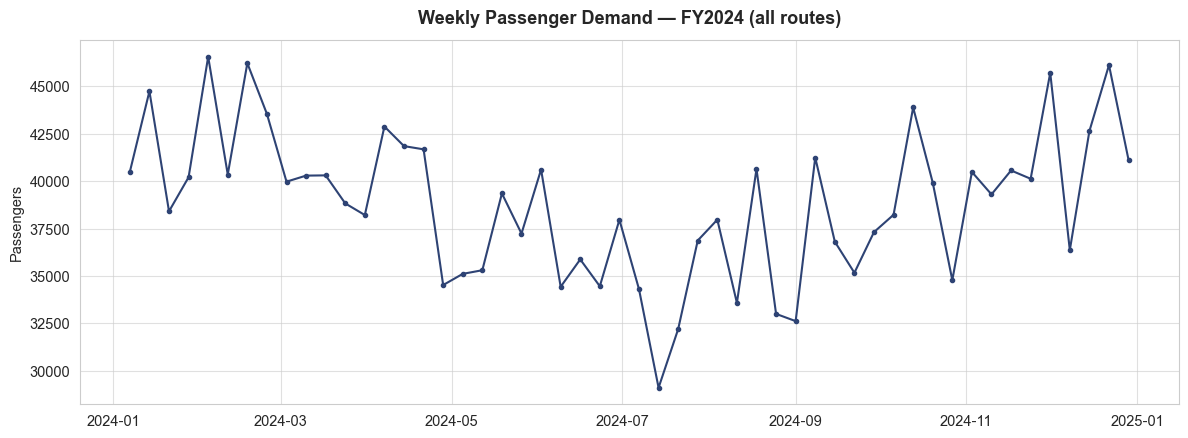

In [27]:

weekly = (df.set_index("Flight_Date")
            .resample("W")
            .agg(Passengers=("Passengers","sum"),
                 Revenue=("Total_Revenue","sum"),
                 Flights=("Flight_Number","count"),
                 Avg_Load_Factor=("Load_Factor","mean"))
            .reset_index())

# Drop any partial (non-7-calendar-day) week at the start/end of the year so a
# short week doesn't distort the trend/forecast (2024-12-31 leaves a 2-day tail week)
full_calendar = pd.Series(1, index=pd.date_range(df.Flight_Date.min(), df.Flight_Date.max()))
days_per_week = full_calendar.resample("W").sum()
full_weeks_mask = (days_per_week == 7).values
weekly = weekly.loc[full_weeks_mask].reset_index(drop=True)

weekly["WeekIdx"] = np.arange(len(weekly))
weekly["MonthOfYear"] = weekly.Flight_Date.dt.month
print(f"Using {len(weekly)} complete weeks (partial first/last weeks excluded).")

def make_ts_features(s, name, lags=(1,2,3), roll_windows=(3,4)):
    out = pd.DataFrame({name: s})
    for l in lags:
        out[f"{name}_lag{l}"] = s.shift(l)
    for w in roll_windows:
        out[f"{name}_rollmean{w}"] = s.shift(1).rolling(w).mean()
    return out

feat_pax = make_ts_features(weekly.Passengers, "Passengers")
ts = pd.concat([weekly[["Flight_Date","WeekIdx","MonthOfYear"]], feat_pax], axis=1).dropna().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(weekly.Flight_Date, weekly.Passengers, marker="o", ms=3, color=ACCENT_BLUE)
ax.set_title("Weekly Passenger Demand: FY2024 (all routes)")
ax.set_ylabel("Passengers")
savefig(fig, "14_weekly_demand_series")
plt.show()


In [28]:

FEATURES = [c for c in ts.columns if c not in ("Flight_Date","Passengers")]
TEST_WEEKS = 8
train, test = ts.iloc[:-TEST_WEEKS], ts.iloc[-TEST_WEEKS:]

X_train, y_train = train[FEATURES], train["Passengers"]
X_test, y_test = test[FEATURES], test["Passengers"]

lr = LinearRegression().fit(X_train, y_train)
rf_dem = RandomForestRegressor(n_estimators=400, max_depth=5, random_state=42, n_jobs=-1).fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_rf = rf_dem.predict(X_test)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"{label:20s}  MAE={mae:8.0f}  RMSE={rmse:8.0f}  MAPE={mape:5.1f}%")
    return mae, rmse, mape

print("Hold-out performance (last 8 weeks):")
evaluate(y_test.values, pred_lr, "Linear Regression")
evaluate(y_test.values, pred_rf, "Random Forest")


Hold-out performance (last 8 weeks):
Linear Regression     MAE=    4434  RMSE=    4880  MAPE= 10.5%
Random Forest         MAE=    4239  RMSE=    4986  MAPE=  9.8%


(4238.6998520266425, 4986.1194953843, 9.847796588946167)

Saved -> outputs/figures/15_demand_backtest.png


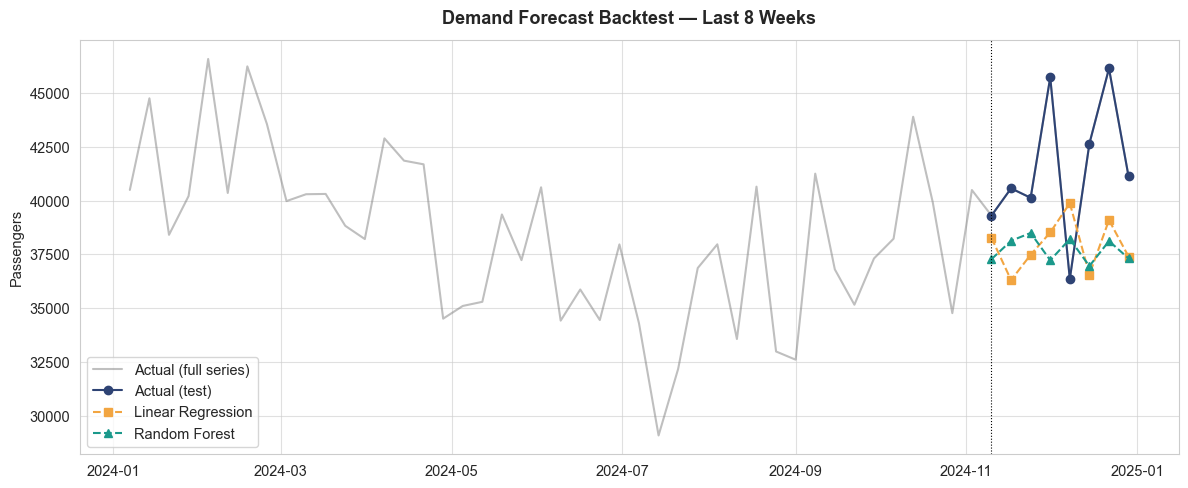

In [29]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.Flight_Date, weekly.Passengers, color="grey", alpha=0.5, label="Actual (full series)")
ax.plot(test.Flight_Date, y_test, marker="o", color=ACCENT_BLUE, label="Actual (test)")
ax.plot(test.Flight_Date, pred_lr, marker="s", ls="--", color=ACCENT_GOLD, label="Linear Regression")
ax.plot(test.Flight_Date, pred_rf, marker="^", ls="--", color=ACCENT_GREEN, label="Random Forest")
ax.axvline(test.Flight_Date.iloc[0], color="black", lw=0.8, ls=":")
ax.set_title("Demand Forecast Backtest: Last 8 Weeks")
ax.set_ylabel("Passengers")
ax.legend()
savefig(fig, "15_demand_backtest")
plt.show()


In [30]:

# Recursive 6-week-ahead forecast with the Random Forest (better hold-out MAPE)
FORECAST_WEEKS = 6
history = weekly[["Flight_Date","Passengers"]].copy()
future_rows = []

for step in range(FORECAST_WEEKS):
    s = history.set_index("Flight_Date")["Passengers"]
    last_date = history.Flight_Date.iloc[-1]
    next_date = last_date + pd.Timedelta(weeks=1)
    row = {
        "WeekIdx": len(history),
        "MonthOfYear": next_date.month,
        "Passengers_lag1": s.iloc[-1],
        "Passengers_lag2": s.iloc[-2],
        "Passengers_lag3": s.iloc[-3],
        "Passengers_rollmean3": s.iloc[-3:].mean(),
        "Passengers_rollmean4": s.iloc[-4:].mean(),
    }
    X_next = pd.DataFrame([row])[FEATURES]
    pred = rf_dem.predict(X_next)[0]
    future_rows.append({"Flight_Date": next_date, "Passengers": pred})
    history = pd.concat([history, pd.DataFrame([{"Flight_Date": next_date, "Passengers": pred}])], ignore_index=True)

forecast_df = pd.DataFrame(future_rows)
forecast_df.to_csv(REPORT_DIR / "demand_forecast_next_6_weeks.csv", index=False)
print("Saved -> outputs/reports/demand_forecast_next_6_weeks.csv")
forecast_df


Saved -> outputs/reports/demand_forecast_next_6_weeks.csv


,Flight_Date,Passengers
0,2025-01-05,38070.119691
1,2025-01-12,38342.779006
2,2025-01-19,39250.317461
3,2025-01-26,38858.869200
4,2025-02-02,38953.204634
5,2025-02-09,39038.130200


Saved -> outputs/figures/16_demand_forecast.png


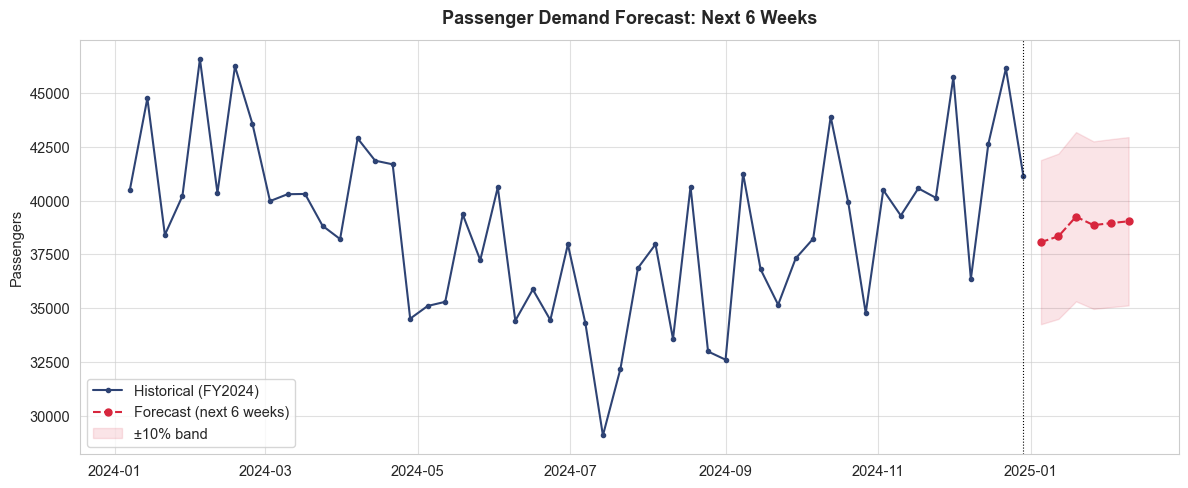

In [31]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.Flight_Date, weekly.Passengers, marker="o", ms=3, color=ACCENT_BLUE, label="Historical (FY2024)")
ax.plot(forecast_df.Flight_Date, forecast_df.Passengers, marker="o", ms=5, ls="--",
        color=ACCENT_RED, label="Forecast (next 6 weeks)")
ax.axvline(weekly.Flight_Date.iloc[-1], color="black", lw=0.8, ls=":")
ax.fill_between(forecast_df.Flight_Date, forecast_df.Passengers*0.9, forecast_df.Passengers*1.1,
                color=ACCENT_RED, alpha=0.12, label="±10% band")
ax.set_title("Passenger Demand Forecast: Next 6 Weeks")
ax.set_ylabel("Passengers")
ax.legend()
savefig(fig, "16_demand_forecast")
plt.show()


## 9. Revenue Forecasting <a id='9'></a>
Same methodology applied to weekly **Total_Revenue**, giving finance a short-horizon
top-line forecast alongside the demand forecast.

Random Forest (Rev)   MAE= 7455514  RMSE= 8753913  MAPE= 13.7%
Saved -> outputs/reports/revenue_forecast_next_6_weeks.csv
Saved -> outputs/figures/17_revenue_forecast.png


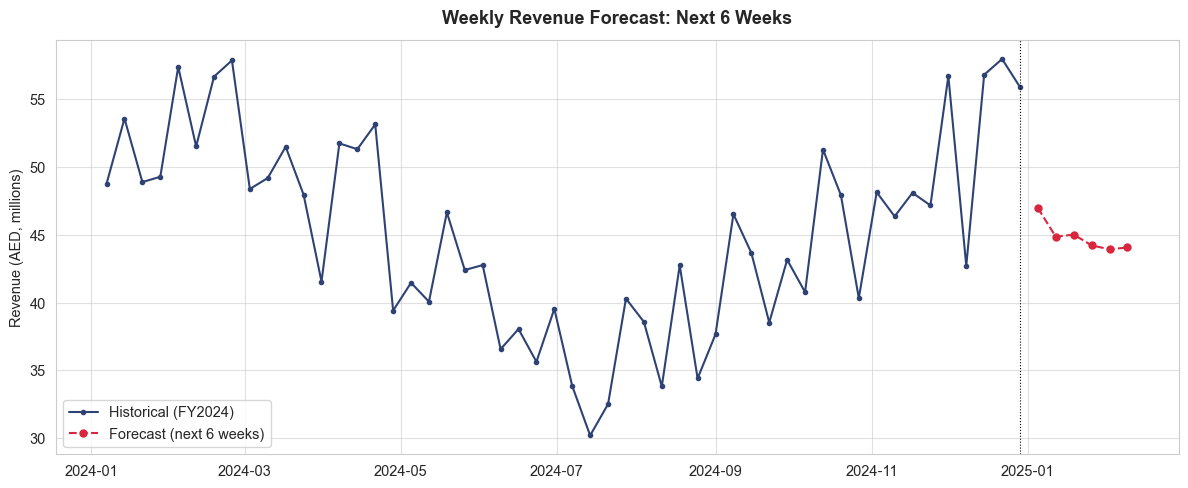

,Flight_Date,Revenue
0,2025-01-05,4.696378e+07
1,2025-01-12,4.485250e+07
2,2025-01-19,4.501214e+07
3,2025-01-26,4.421816e+07
4,2025-02-02,4.392610e+07
5,2025-02-09,4.406091e+07


In [32]:

feat_rev = make_ts_features(weekly.Revenue, "Revenue")
ts_rev = pd.concat([weekly[["Flight_Date","WeekIdx","MonthOfYear"]], feat_rev], axis=1).dropna().reset_index(drop=True)

FEATURES_REV = [c for c in ts_rev.columns if c not in ("Flight_Date","Revenue")]
train_r, test_r = ts_rev.iloc[:-TEST_WEEKS], ts_rev.iloc[-TEST_WEEKS:]
X_train_r, y_train_r = train_r[FEATURES_REV], train_r["Revenue"]
X_test_r, y_test_r   = test_r[FEATURES_REV], test_r["Revenue"]

rf_rev = RandomForestRegressor(n_estimators=400, max_depth=5, random_state=42, n_jobs=-1).fit(X_train_r, y_train_r)
pred_rev = rf_rev.predict(X_test_r)
evaluate(y_test_r.values, pred_rev, "Random Forest (Rev)")

# Recursive forecast
history_r = weekly[["Flight_Date","Revenue"]].copy()
future_rev = []
for step in range(FORECAST_WEEKS):
    s = history_r.set_index("Flight_Date")["Revenue"]
    next_date = history_r.Flight_Date.iloc[-1] + pd.Timedelta(weeks=1)
    row = {
        "WeekIdx": len(history_r), "MonthOfYear": next_date.month,
        "Revenue_lag1": s.iloc[-1], "Revenue_lag2": s.iloc[-2], "Revenue_lag3": s.iloc[-3],
        "Revenue_rollmean3": s.iloc[-3:].mean(), "Revenue_rollmean4": s.iloc[-4:].mean(),
    }
    X_next = pd.DataFrame([row])[FEATURES_REV]
    pred = rf_rev.predict(X_next)[0]
    future_rev.append({"Flight_Date": next_date, "Revenue": pred})
    history_r = pd.concat([history_r, pd.DataFrame([{"Flight_Date": next_date, "Revenue": pred}])], ignore_index=True)

forecast_rev_df = pd.DataFrame(future_rev)
forecast_rev_df.to_csv(REPORT_DIR / "revenue_forecast_next_6_weeks.csv", index=False)
print("Saved -> outputs/reports/revenue_forecast_next_6_weeks.csv")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.Flight_Date, weekly.Revenue/1e6, marker="o", ms=3, color=ACCENT_BLUE, label="Historical (FY2024)")
ax.plot(forecast_rev_df.Flight_Date, forecast_rev_df.Revenue/1e6, marker="o", ms=5, ls="--",
        color=ACCENT_RED, label="Forecast (next 6 weeks)")
ax.axvline(weekly.Flight_Date.iloc[-1], color="black", lw=0.8, ls=":")
ax.set_ylabel("Revenue (AED, millions)")
ax.set_title("Weekly Revenue Forecast: Next 6 Weeks")
ax.legend()
savefig(fig, "17_revenue_forecast")
plt.show()

forecast_rev_df


## 10. Executive Dashboard <a id='10'></a>
A single-page, print-ready dashboard summarizing the KPIs a route-planning /
commercial-strategy audience would want to see at a glance.

Saved -> outputs/figures/18_executive_dashboard.png


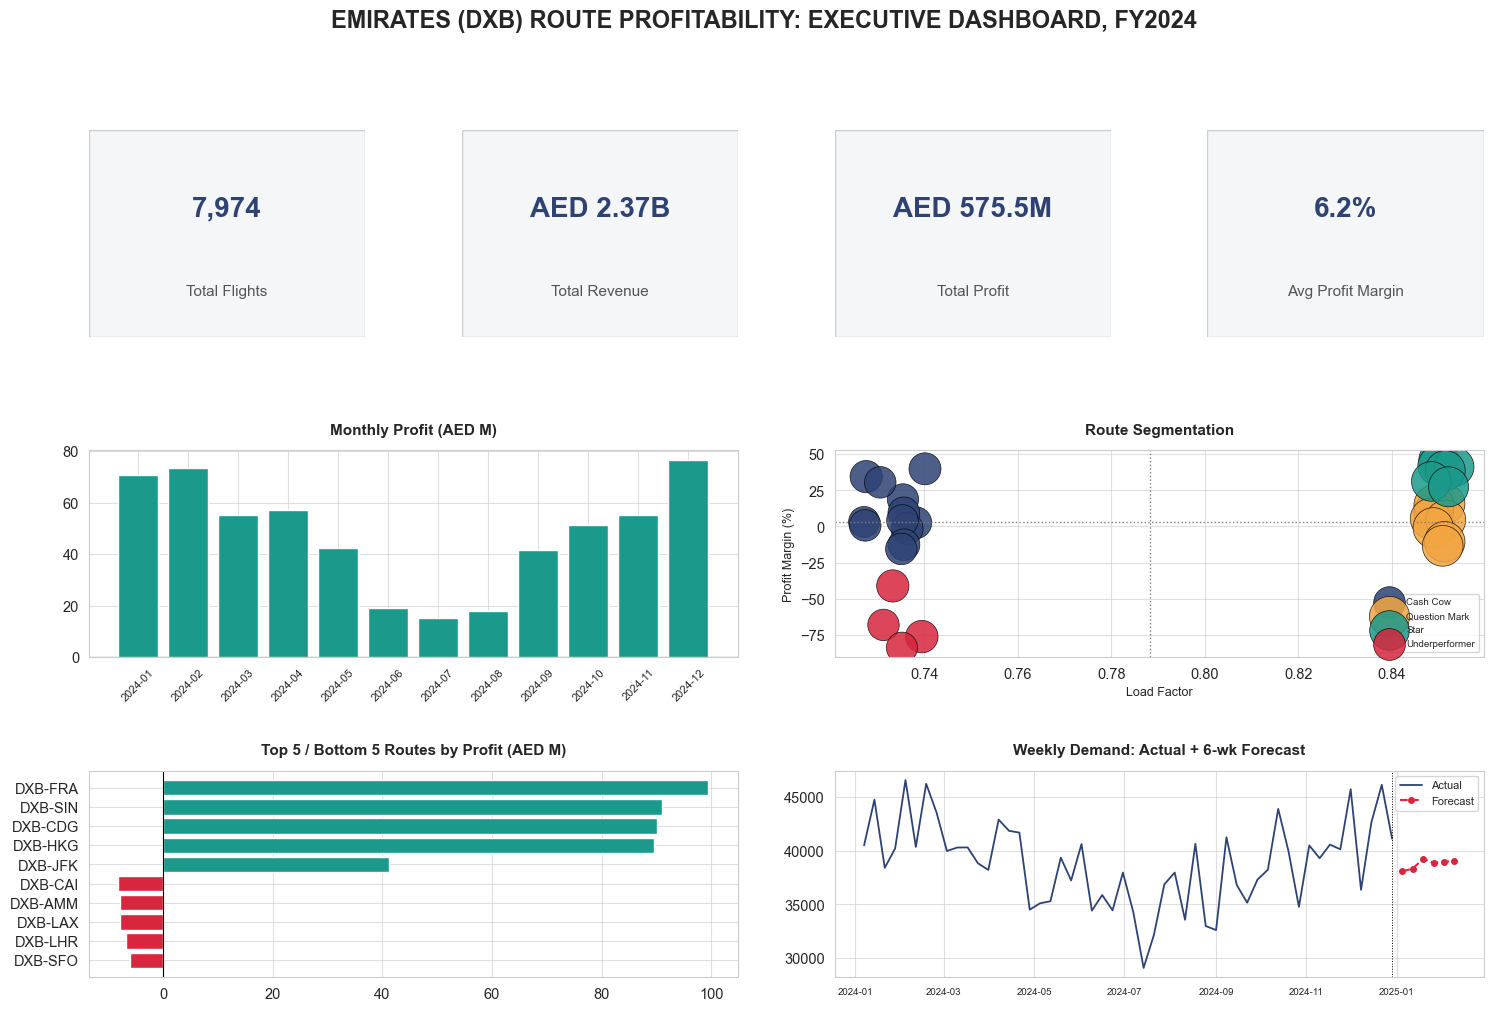

In [33]:

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.35)
fig.suptitle("EMIRATES (DXB) ROUTE PROFITABILITY: EXECUTIVE DASHBOARD, FY2024",
             fontsize=17, fontweight="bold", y=0.99)

# --- KPI cards (top row) ------------------------------------------------
kpis = [
    ("Total Flights", f"{len(df):,}"),
    ("Total Revenue", f"AED {df.Total_Revenue.sum()/1e9:.2f}B"),
    ("Total Profit", f"AED {df.Profit.sum()/1e6:.1f}M"),
    ("Avg Profit Margin", f"{df.Profit_Margin.mean():.1f}%"),
]
for i, (label, value) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0,0), 1, 1, transform=ax.transAxes,
                                 facecolor="#F4F6F8", edgecolor="#cccccc"))
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=20, fontweight="bold", color=ACCENT_BLUE)
    ax.text(0.5, 0.22, label, ha="center", va="center", fontsize=11, color="#555555")

# --- Monthly profit trend ------------------------------------------------
ax1 = fig.add_subplot(gs[1, :2])
colors_bar = [ACCENT_GREEN if p>=0 else ACCENT_RED for p in monthly.Profit]
ax1.bar(monthly.YearMonth, monthly.Profit/1e6, color=colors_bar)
ax1.axhline(0, color="black", lw=0.8)
ax1.set_title("Monthly Profit (AED M)", fontsize=11)
ax1.tick_params(axis="x", rotation=45, labelsize=8)

# --- Route segmentation --------------------------------------------------
ax2 = fig.add_subplot(gs[1, 2:])
for seg, sub in route_summary.groupby("Segment"):
    ax2.scatter(sub.Avg_Load_Factor, sub.Avg_Profit_Margin, s=sub.Flights*2.5,
                color=seg_colors[seg], edgecolor="black", linewidth=0.5, alpha=0.85, label=seg)
ax2.axhline(overall_pm, color="grey", ls=":", lw=1)
ax2.axvline(overall_lf, color="grey", ls=":", lw=1)
ax2.set_title("Route Segmentation", fontsize=11)
ax2.set_xlabel("Load Factor", fontsize=9); ax2.set_ylabel("Profit Margin (%)", fontsize=9)
ax2.legend(fontsize=7, loc="lower right")

# --- Top / bottom routes --------------------------------------------------
ax3 = fig.add_subplot(gs[2, :2])
top5 = route_summary.head(5); bot5 = route_summary.tail(5).sort_values("Total_Profit")
combo = pd.concat([top5, bot5])
colors_combo = [ACCENT_GREEN if v>=0 else ACCENT_RED for v in combo.Total_Profit]
ax3.barh(combo.Route, combo.Total_Profit/1e6, color=colors_combo)
ax3.axvline(0, color="black", lw=0.8)
ax3.set_title("Top 5 / Bottom 5 Routes by Profit (AED M)", fontsize=11)
ax3.invert_yaxis()

# --- Demand forecast -------------------------------------------------------
ax4 = fig.add_subplot(gs[2, 2:])
ax4.plot(weekly.Flight_Date, weekly.Passengers, color=ACCENT_BLUE, lw=1.3, label="Actual")
ax4.plot(forecast_df.Flight_Date, forecast_df.Passengers, color=ACCENT_RED, ls="--", marker="o", ms=4, label="Forecast")
ax4.axvline(weekly.Flight_Date.iloc[-1], color="black", lw=0.7, ls=":")
ax4.set_title("Weekly Demand: Actual + 6-wk Forecast", fontsize=11)
ax4.tick_params(axis="x", labelsize=7)
ax4.legend(fontsize=8)

savefig(fig, "18_executive_dashboard", tight=False)
plt.show()


In [56]:

try:
    import ipywidgets as widgets
    from IPython.display import display

    season_dropdown = widgets.Dropdown(
        options=["All"] + season_order, value="All", description="Season:"
    )
    out = widgets.Output()

    def render(change=None):
        out.clear_output(wait=True)
        with out:
            sel = season_dropdown.value
            data = df if sel == "All" else df[df.Season == sel]
            rs = (data.groupby("Route")
                       .agg(Avg_Load_Factor=("Load_Factor","mean"),
                            Avg_Profit_Margin=("Profit_Margin","mean"),
                            Flights=("Flight_Number","count"))
                       .reset_index())
            fig, ax = plt.subplots(figsize=(9, 5.5))
            sc = ax.scatter(rs.Avg_Load_Factor, rs.Avg_Profit_Margin, s=rs.Flights*4,
                             c=rs.Avg_Profit_Margin, cmap="RdYlGn", edgecolor="black", alpha=0.85)
            for _, r in rs.iterrows():
                ax.annotate(r.Route, (r.Avg_Load_Factor, r.Avg_Profit_Margin), fontsize=7,
                            xytext=(3,3), textcoords="offset points")
            ax.axhline(0, color="grey", ls="--", lw=1)
            ax.set_title(f"Route Profitability Season: {sel}")
            ax.set_xlabel("Load Factor"); ax.set_ylabel("Profit Margin (%)")
            plt.show()

    season_dropdown.observe(render, names="value")
    display(season_dropdown, out)
    render()
except ImportError:
    print("ipywidgets not installed: skipping interactive widget.")
    print("Run:  pip install ipywidgets   then re-execute this cell for the interactive version.")


Dropdown(description='Season:', options=('All', 'Low', 'Shoulder', 'Normal', 'Peak'), value='All')

Output()

## 11. Key Insights & Recommendations <a id='11'></a>

In [35]:

best_route = route_summary.iloc[0]
worst_route = route_summary.sort_values("Total_Profit").iloc[0]
best_season = season_profit.idxmax()
worst_season = season_profit.idxmin()
best_aircraft = fleet.sort_values("Avg_Profit_Margin", ascending=False).index[0]
worst_aircraft = fleet.sort_values("Avg_Profit_Margin").index[0]
n_loss_routes = int((route_summary.Total_Profit < 0).sum())

summary = f'''
KEY INSIGHTS: GENERATED FROM FY2024 DATA
================================================================
1. PORTFOLIO HEALTH
   - {len(df):,} flights across {df.Route.nunique()} routes generated
     AED {df.Total_Revenue.sum()/1e9:.2f}B revenue and AED {df.Profit.sum()/1e6:.1f}M profit
     (avg margin {df.Profit_Margin.mean():.1f}%).
   - {(df.Profit<0).mean()*100:.1f}% of individual flights were loss-making;
     {n_loss_routes} of {len(route_summary)} routes are net loss-making for the full year.

2. ROUTE PERFORMANCE
   - Best route: {best_route.Route} (AED {best_route.Total_Profit/1e6:.1f}M profit,
     {best_route.Avg_Profit_Margin:.1f}% avg margin).
   - Weakest route: {worst_route.Route} (AED {worst_route.Total_Profit/1e6:.1f}M profit,
     {worst_route.Avg_Profit_Margin:.1f}% avg margin) candidate for capacity/schedule review.

3. SEASONALITY
   - {best_season} season delivers the strongest margins ({season_profit.max():.1f}%);
     {worst_season} season is weakest ({season_profit.min():.1f}%) consider dynamic
     pricing / capacity adjustment ahead of low-demand periods.

4. FLEET
   - {best_aircraft} has the best average margin among the fleet;
     {worst_aircraft} the weakest worth reviewing route-aircraft assignment.

5. WHAT DRIVES MARGIN
   - Load Factor correlates {corr_lf_pm:+.2f} with Profit Margin filling seats matters,
     but the feature-importance analysis (Section 7) shows aircraft type and route
     category matter just as much as load factor alone.

6. FORECASTING
   - Weekly demand and revenue forecasts (Section 8-9) project the next 6 weeks;
     Random Forest outperformed the linear baseline on hold-out MAPE in the backtest.

RECOMMENDATIONS
================================================================
 - Reassess or restructure the {n_loss_routes} structurally loss-making routes:
   right-size aircraft, adjust frequency, or renegotiate airport/handling fees.
 - Shift capacity toward Star/Cash-Cow routes (Section 6) during {worst_season} season.
 - Use the fleet unit-economics view (Section 5.4) to guide aircraft-route matching
   assign higher-CASK aircraft only to routes with strong RASK.
 - Feed the 6-week demand/revenue forecast into crew and inventory planning.
'''
print(summary)

with open(REPORT_DIR / "executive_summary.txt", "w") as f:
    f.write(summary)
print("Saved -> outputs/reports/executive_summary.txt")



KEY INSIGHTS: GENERATED FROM FY2024 DATA
1. PORTFOLIO HEALTH
   - 7,974 flights across 30 routes generated
     AED 2.37B revenue and AED 575.5M profit
     (avg margin 6.2%).
   - 33.7% of individual flights were loss-making;
     8 of 30 routes are net loss-making for the full year.

2. ROUTE PERFORMANCE
   - Best route: DXB-FRA (AED 99.5M profit,
     46.1% avg margin).
   - Weakest route: DXB-CAI (AED -8.2M profit,
     -84.0% avg margin) candidate for capacity/schedule review.

3. SEASONALITY
   - Peak season delivers the strongest margins (17.5%);
     Low season is weakest (-8.5%) consider dynamic
     pricing / capacity adjustment ahead of low-demand periods.

4. FLEET
   - Airbus A380 has the best average margin among the fleet;
     Boeing 737-800 the weakest worth reviewing route-aircraft assignment.

5. WHAT DRIVES MARGIN
   - Load Factor correlates +0.42 with Profit Margin filling seats matters,
     but the feature-importance analysis (Section 7) shows aircraft type and 

---
### Reproducing this analysis
```
Airline Route Profitability/
├── data/Airline_Route_Profitability.csv
├── notebooks/Airline_Route_Profitability_Analysis.ipynb   <- this file
├── outputs/
│   ├── figures/     18 saved PNG charts
│   ├── reports/     cleaned data, route summary, forecasts, executive summary
│   └── models/
├── requirements.txt
└── README.md
```
Run `pip install -r requirements.txt`, then execute the notebook top-to-bottom
(`Kernel → Restart & Run All`). Every chart is saved to `outputs/figures/` and every
table to `outputs/reports/` as the notebook runs.
